# Quiz 1

Step 1：先讀取並了解 Dataset

本次使用 Intel Image Classification Dataset 進行影像分類。

資料集包含 6 個類別：

- buildings
- forest
- glacier
- mountain
- sea
- street

本次任務為 Multi-class Image Classification，
目標是訓練 CNN 模型，根據輸入的自然場景影像，
將影像分類為上述六個類別之一。

In [1]:
from pathlib import Path

# Dataset 路徑
DATA_ROOT = Path("data/Intel_Image_Classification")

TRAIN_DIR = DATA_ROOT / "seg_train" / "seg_train"
TEST_DIR = DATA_ROOT / "seg_test" / "seg_test"
PRED_DIR = DATA_ROOT / "seg_pred" / "seg_pred"

print("Train path:", TRAIN_DIR)
print("Test path :", TEST_DIR)
print("Pred path :", PRED_DIR)

print("\nPath exists:")
print("Train:", TRAIN_DIR.exists())
print("Test :", TEST_DIR.exists())
print("Pred :", PRED_DIR.exists())

Train path: data\Intel_Image_Classification\seg_train\seg_train
Test path : data\Intel_Image_Classification\seg_test\seg_test
Pred path : data\Intel_Image_Classification\seg_pred\seg_pred

Path exists:
Train: True
Test : True
Pred : True


Step 2：統計 Train / Test

In [2]:
# 取得所有類別名稱
class_names = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

# 支援的圖片格式
image_extensions = {".jpg", ".jpeg", ".png"}

print("\nTraining Dataset:")
total_train = 0

for class_name in class_names:
    class_dir = TRAIN_DIR / class_name

    images = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    print(f"{class_name:10s}: {len(images)} images")
    total_train += len(images)

print("Total:", total_train)


print("\nTesting Dataset:")
total_test = 0

for class_name in class_names:
    class_dir = TEST_DIR / class_name

    images = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    print(f"{class_name:10s}: {len(images)} images")
    total_test += len(images)

print("Total:", total_test)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6

Training Dataset:
buildings : 2191 images
forest    : 2271 images
glacier   : 2404 images
mountain  : 2512 images
sea       : 2274 images
street    : 2382 images
Total: 14034

Testing Dataset:
buildings : 437 images
forest    : 474 images
glacier   : 553 images
mountain  : 525 images
sea       : 510 images
street    : 501 images
Total: 3000


Step 3： Dataset Split

原始資料集包含：

- Training Dataset：14,034 張影像
- Testing Dataset：3,000 張影像
- Classes：6 類

本實驗將原始 Training Dataset 再切分為：

- Training：80%
- Validation：20%

原始 `seg_test` 則保留作為最終 Testing Dataset，
不參與模型訓練與 Validation。

Training Dataset 用於更新模型參數；
Validation Dataset 用於訓練過程中評估模型的泛化能力；
Testing Dataset 則用於模型訓練完成後的最終效能評估。

Step 4：顯示 Dataset 的圖片

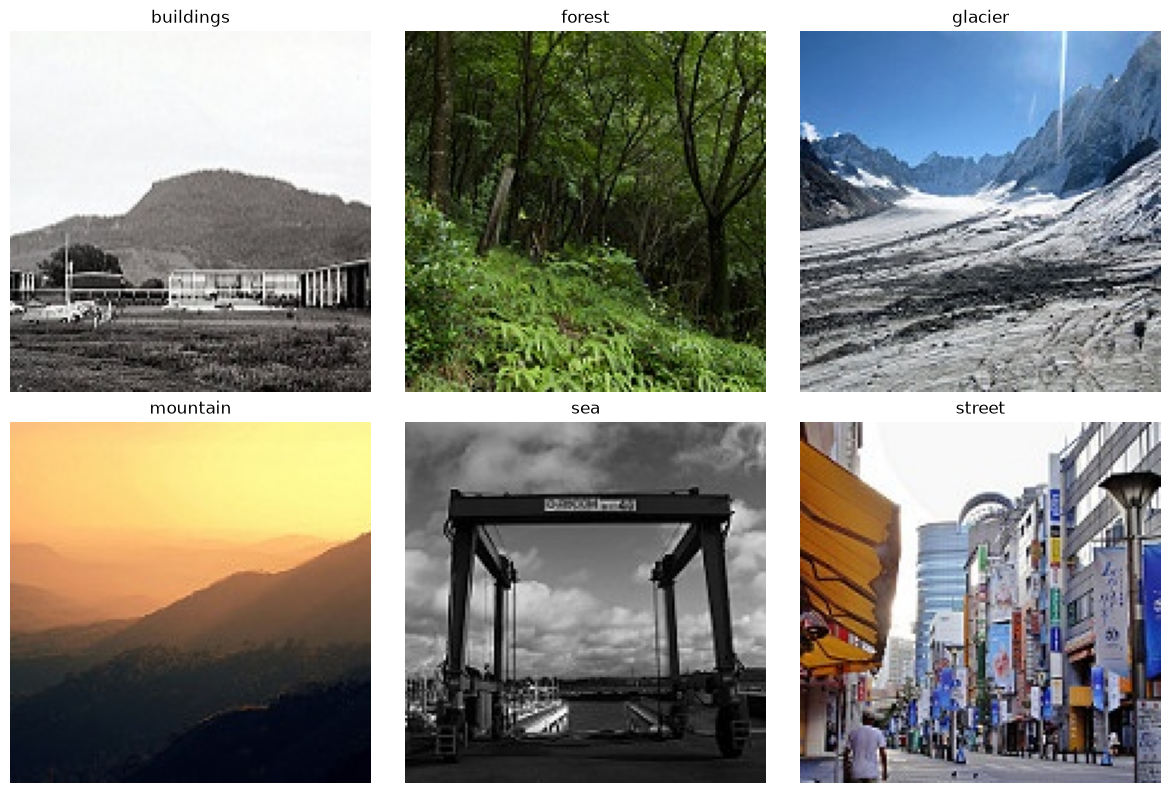

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_dir = TRAIN_DIR / class_name

    # 找出這個類別中的第一張圖片
    image_path = next(class_dir.glob("*.jpg"))

    # 讀取圖片
    image = Image.open(image_path)

    # 顯示圖片
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 5：建立 TensorFlow Dataset

In [4]:
import os

os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
# 基本設定
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

# Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Testing Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

TensorFlow version: 2.21.0
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


In [5]:
print("Class names:", train_ds.class_names)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Labels:", labels.numpy())

Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Image batch shape: (32, 150, 150, 3)
Label batch shape: (32,)
Labels: [1 5 5 1 1 3 0 4 1 2 3 4 5 5 5 4 2 5 4 2 5 0 4 2 4 0 5 4 1 1 2 3]


## Quiz 1：Dataset Preparation

### 1. Dataset

本次實驗使用 **Intel Image Classification Dataset**，
Dataset Source：  
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

資料內容為自然場景影像，共包含 6 個類別：

- buildings
- forest
- glacier
- mountain
- sea
- street

原始 Training Dataset 共包含 **14,034 張影像**，
Testing Dataset 共包含 **3,000 張影像**。

各類別的 Training Dataset 數量如下：

| Class | Number of Images |
|---|---:|
| buildings | 2191 |
| forest | 2271 |
| glacier | 2404 |
| mountain | 2512 |
| sea | 2274 |
| street | 2382 |

各類別影像數量相近，因此沒有明顯的類別不平衡問題。

### 2. Dataset Split

將原始 Training Dataset 以 **80% / 20%** 切分為：

- Training Dataset：11,228 張
- Validation Dataset：2,806 張

另外保留原始 Testing Dataset 的 3,000 張影像，
作為模型訓練完成後的最終測試資料，不參與模型訓練。

Training Dataset 用於模型參數更新；
Validation Dataset 用於訓練過程中評估模型的泛化能力；
Testing Dataset 則用於最終模型效能評估。

### 3. Classification Problem

本次任務為 **Multi-class Image Classification**。

模型輸入為自然場景 RGB 影像，
經過 Resize 後統一為 **150 × 150 × 3**，
模型需要判斷輸入影像屬於 buildings、forest、glacier、
mountain、sea、street 六個類別中的哪一類。

因此模型最終需要輸出 6 個類別的預測結果。

# Quiz 2：CNN Image Classification


本實驗首先自行設計一個 Plain CNN，
使用多層 Convolution 與 Max Pooling 進行影像特徵提取，
最後透過 Dense Layer 進行六類自然場景影像分類。

Step 1：設計 Plain CNN

In [6]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

plain_cnn = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # 將 RGB pixel 從 0~255 正規化到 0~1
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

plain_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Step 2：Compile 模型

In [7]:
plain_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy"
        )
    ]
)

Step 3：正式開始 Training

In [8]:
EPOCHS = 5

history_plain = plain_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


D:\anaconda\envs\MMIP\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 220s 606ms/step - accuracy: 0.6322 - loss: 0.9503 - top5_accuracy: 0.9874 - val_accuracy: 0.6711 - val_loss: 0.8548 - val_top5_accuracy: 0.9954
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 187s 532ms/step - accuracy: 0.7803 - loss: 0.6037 - top5_accuracy: 0.9979 - val_accuracy: 0.7769 - val_loss: 0.6377 - val_top5_accuracy: 0.9979
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 166s 473ms/step - accuracy: 0.8335 - loss: 0.4522 - top5_accuracy: 0.9992 - val_accuracy: 0.7954 - val_loss: 0.6160 - val_top5_accuracy: 0.9968
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 122s 348ms/step - accuracy: 0.8896 - loss: 0.3125 - top5_accuracy: 0.9997 - val_accuracy: 0.7965 - val_loss: 0.6839 - val_top5_accuracy: 0.9957
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 122s 346ms/step - accuracy: 0.9292 - loss: 0.2061 - top5_accuracy: 0.9996 - val_accuracy: 0.7894 - val_loss: 0.7831 - val_top5_accuracy: 0.9975


Step 2：用 Testing Dataset 評估模型

In [9]:
test_results = plain_cnn.evaluate(test_ds)

print("Test Loss:", test_results[0])
print("Test Top-1 Accuracy:", test_results[1])
print("Test Top-5 Accuracy:", test_results[2])

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.8003 - loss: 0.7786 - top5_accuracy: 0.9980
Test Loss: 0.7785546183586121
Test Top-1 Accuracy: 0.8003333210945129
Test Top-5 Accuracy: 0.9980000257492065


Step 3：Classic CNN Backbone

Step 3-1：建立 ResNet50

In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 建立 ResNet50 Backbone
resnet_base = ResNet50(
    weights=None,          # 從頭訓練，不使用 ImageNet 預訓練權重
    include_top=False,     # 不使用 ResNet50 原本的分類層
    input_shape=(150, 150, 3)
)

resnet_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    
    # 將 0~255 轉成 ResNet50 所需的輸入格式
    layers.Lambda(
        tf.keras.applications.resnet50.preprocess_input
    ),

    # Backbone
    resnet_base,

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(6, activation="softmax")
])

resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                      │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 5, 5, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │          12,294 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 23,546,886 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

Step 3-2：Compile ResNet50

In [11]:
resnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy"
        )
    ]
)

In [12]:
EPOCHS = 5

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1850s 5s/step - accuracy: 0.5926 - loss: 1.2053 - top5_accuracy: 0.9858 - val_accuracy: 0.6782 - val_loss: 0.8572 - val_top5_accuracy: 0.9943
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1766s 5s/step - accuracy: 0.7148 - loss: 0.8040 - top5_accuracy: 0.9939 - val_accuracy: 0.6172 - val_loss: 17.1640 - val_top5_accuracy: 0.9950
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1746s 5s/step - accuracy: 0.7578 - loss: 0.6997 - top5_accuracy: 0.9962 - val_accuracy: 0.7167 - val_loss: 0.7966 - val_top5_accuracy: 0.9975
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1746s 5s/step - accuracy: 0.7854 - loss: 0.6027 - top5_accuracy: 0.9971 - val_accuracy: 0.7060 - val_loss: 0.9051 - val_top5_accuracy: 0.9996
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1743s 5s/step - accuracy: 0.8178 - loss: 0.5045 - top5_accuracy: 0.9982 - val_accuracy: 0.7741 - val_loss: 0.6486 - val_top5_accuracy: 0.9954


Step 4 用 Testing Dataset 評估模型

In [13]:
test_results_resnet = resnet_model.evaluate(test_ds)

print("ResNet50 Test Loss:", test_results_resnet[0])
print("ResNet50 Test Top-1 Accuracy:", test_results_resnet[1])
print("ResNet50 Test Top-5 Accuracy:", test_results_resnet[2])

94/94 ━━━━━━━━━━━━━━━━━━━━ 88s 935ms/step - accuracy: 0.7537 - loss: 0.6997 - top5_accuracy: 0.9950
ResNet50 Test Loss: 0.6997044086456299
ResNet50 Test Top-1 Accuracy: 0.7536666393280029
ResNet50 Test Top-5 Accuracy: 0.9950000047683716


Step 5：ROC / AUC

In [15]:
import numpy as np

# 真實標籤
y_true = np.concatenate([
    y.numpy() for x, y in test_ds
])

# Plain CNN 預測機率
y_prob_plain = plain_cnn.predict(test_ds)

# ResNet50 預測機率
y_prob_resnet = resnet_model.predict(test_ds)

print("y_true shape:", y_true.shape)
print("Plain CNN prediction shape:", y_prob_plain.shape)
print("ResNet50 prediction shape:", y_prob_resnet.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 965ms/step
y_true shape: (3000,)
Plain CNN prediction shape: (3000, 6)
ResNet50 prediction shape: (3000, 6)


計算每個類別的 ROC / AUC

In [17]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 3.3 MB/s eta 0:00:03
   --------------------- ------------------ 4.5/8.3 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 18.4 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---- ----------------------------------- 3.7/36.6 MB 19.8 MB/s eta 0:00:02
   ------- -------------------------------- 6.6/36.6 MB 16.8 MB/s eta 0:00:02
   ---------- ----------------------------- 9.7/36.6 MB 15.9 MB/s eta 0:00:02
   ------------ --------------------------- 11.8/36.6 MB 14.5 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/36.6 MB 14.0 MB/s eta 0:00:02
   ------------------------------ --------- 27.5/36.6 MB 22.4 MB/s eta 0:00:01
   ------------------------------------ --- 33.6/36.6 MB 23.4 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 23.6 MB/s eta 0:00:01
   --

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# 將標籤轉成 One-vs-Rest 格式
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plain_auc = {}
resnet_auc = {}

for i, class_name in enumerate(class_names):

    # Plain CNN
    fpr_plain, tpr_plain, _ = roc_curve(
        y_true_bin[:, i],
        y_prob_plain[:, i]
    )
    plain_auc[class_name] = auc(fpr_plain, tpr_plain)

    # ResNet50
    fpr_resnet, tpr_resnet, _ = roc_curve(
        y_true_bin[:, i],
        y_prob_resnet[:, i]
    )
    resnet_auc[class_name] = auc(fpr_resnet, tpr_resnet)


print("Plain CNN AUC:")
for class_name, score in plain_auc.items():
    print(f"{class_name:10s}: {score:.4f}")

print("\nResNet50 AUC:")
for class_name, score in resnet_auc.items():
    print(f"{class_name:10s}: {score:.4f}")

Plain CNN AUC:
buildings : 0.9534
forest    : 0.9946
glacier   : 0.9454
mountain  : 0.9543
sea       : 0.9625
street    : 0.9706

ResNet50 AUC:
buildings : 0.9612
forest    : 0.9881
glacier   : 0.9375
mountain  : 0.9525
sea       : 0.9644
street    : 0.9687


Step 5-3：計算 Macro-AUC

In [19]:
macro_auc_plain = np.mean(list(plain_auc.values()))
macro_auc_resnet = np.mean(list(resnet_auc.values()))

print(f"Plain CNN Macro-AUC : {macro_auc_plain:.4f}")
print(f"ResNet50 Macro-AUC  : {macro_auc_resnet:.4f}")

Plain CNN Macro-AUC : 0.9634
ResNet50 Macro-AUC  : 0.9621


Step 5-4：畫 ROC Curve

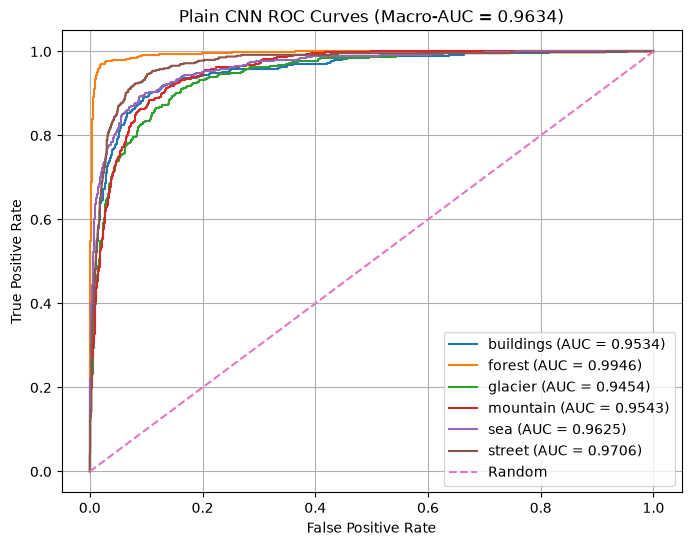

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob_plain[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

# 隨機分類器的基準線
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"Plain CNN ROC Curves (Macro-AUC = {macro_auc_plain:.4f})"
)
plt.legend()
plt.grid()
plt.show()

ResNet50 ROC

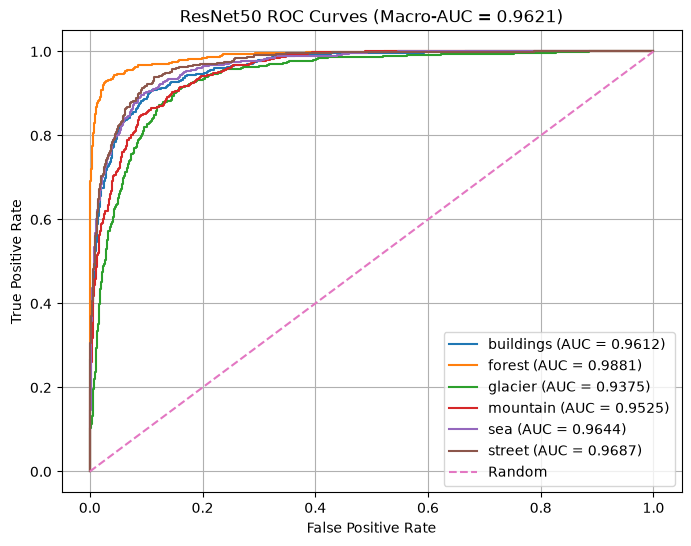

In [21]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob_resnet[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"ResNet50 ROC Curves (Macro-AUC = {macro_auc_resnet:.4f})"
)
plt.legend()
plt.grid()
plt.show()

## Quiz 2 結果分析

### 1. Plain CNN 與 ResNet50 測試結果

本實驗使用 Intel Image Classification Dataset，將影像分為
buildings、forest、glacier、mountain、sea、street 共 6 個類別。

分別建立自行設計的 Plain CNN，以及經典 CNN Backbone ResNet50，
並使用 Testing Dataset（3000 張影像）進行模型評估。

| Model | Test Loss | Top-1 Accuracy | Top-5 Accuracy | Macro-AUC | Parameters |
|---|---:|---:|---:|---:|---:|
| Plain CNN | 0.7786 | 80.03% | 99.80% | 0.9634 | 4,829,126 |
| ResNet50 | 0.6997 | 75.37% | 99.50% | 0.9621 | 23,600,006 |

---

### 2. Accuracy 分析

Plain CNN 的 Test Top-1 Accuracy 為 80.03%，高於 ResNet50 的
75.37%。雖然 ResNet50 的網路架構較深、參數量較多，但在本次實驗
條件下並沒有得到較高的分類正確率。

本實驗中的 ResNet50 使用 `weights=None`，因此模型沒有使用
ImageNet 預訓練權重，而是從隨機初始化開始訓練。由於訓練資料量
與 Epoch 數有限，較大型的 ResNet50 可能尚未充分學習，因此模型
較複雜並不代表在相同訓練條件下一定能得到較好的結果。

此外，兩個模型的 Top-5 Accuracy 都接近 100%。由於本資料集只有
6 個類別，因此 Top-5 只需要讓正確答案出現在機率最高的 5 個類別
之中，所以相較於 Top-1 Accuracy，此資料集的 Top-5 Accuracy
較容易得到很高的數值。

---

### 3. ROC 與 AUC 分析

Plain CNN 各類別 AUC：

- buildings：0.9534
- forest：0.9946
- glacier：0.9454
- mountain：0.9543
- sea：0.9625
- street：0.9706
- Macro-AUC：0.9634

ResNet50 各類別 AUC：

- buildings：0.9612
- forest：0.9881
- glacier：0.9375
- mountain：0.9525
- sea：0.9644
- street：0.9687
- Macro-AUC：0.9621

兩個模型的 Macro-AUC 都超過 0.96，表示兩個模型對不同影像類別
皆具有良好的區分能力。

其中 forest 類別在兩個模型中皆具有最高或接近最高的 AUC，
表示 forest 與其他場景相對容易區分；glacier 的 AUC 相對較低，
表示此類別與其他自然場景的區分較困難。

Plain CNN 的 Macro-AUC 為 0.9634，ResNet50 為 0.9621，
兩者非常接近，Plain CNN 略高。

---

### 4. 模型參數量與訓練成本比較

Plain CNN 共有 4,829,126 個參數，而 ResNet50 共有
23,600,006 個參數，ResNet50 的參數量約為 Plain CNN 的 4.9 倍。

本次使用 CPU 訓練 5 Epoch 時：

- Plain CNN：約 13.6 分鐘
- ResNet50：約 147.5 分鐘

因此 ResNet50 的訓練時間約為 Plain CNN 的 10.8 倍。

雖然 ResNet50 使用更多參數與計算資源，但本次實驗的
Top-1 Accuracy 並沒有超過 Plain CNN。因此可以看出，
增加模型深度與參數量並不一定能在有限資料與有限訓練次數下
得到更好的分類效果。

---

### 5. 結論

在本次實驗條件下，Plain CNN 以較少的參數量與較短的訓練時間，
取得 80.03% 的 Top-1 Accuracy 與 0.9634 的 Macro-AUC，
整體表現優於從頭訓練 5 Epoch 的 ResNet50。

ResNet50 雖然具有更複雜的網路結構，但從隨機初始化開始訓練需要
更多資料與訓練時間才能充分發揮模型能力。後續可嘗試增加訓練
Epoch，或使用 ImageNet 預訓練權重進行 Transfer Learning，
觀察 ResNet50 是否能取得更好的分類效果。

# Quiz 3

Step 1：Plain CNN + Data Augmentation

Step 1-1：建立 Data Augmentation

In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

Step 1-2：先看 Augmentation 長什麼樣

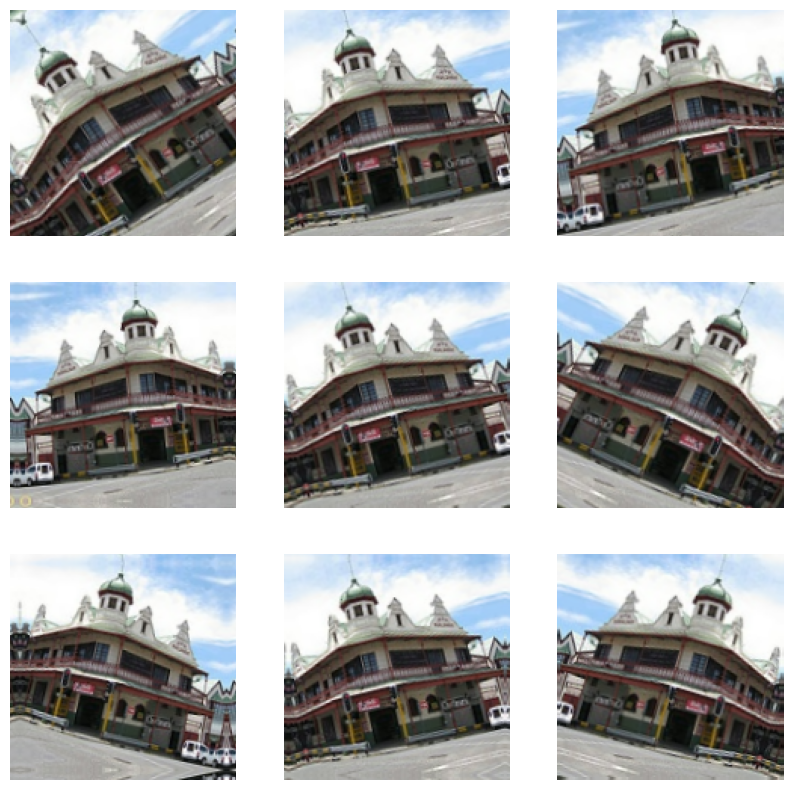

In [23]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    image = images[0]

    plt.figure(figsize=(10, 10))

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(image, 0),
            training=True
        )

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(
            tf.cast(augmented_image[0], tf.uint8)
        )
        plt.axis("off")

    plt.show()

Step 1-3：建立 Plain CNN + Data Augmentation

In [24]:
plain_cnn_aug = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Data Augmentation
    data_augmentation,

    # 與原本 Plain CNN 相同
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

plain_cnn_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Step 1-4：Compile + 訓練 5 Epochs

In [25]:
plain_cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy"
        )
    ]
)

In [26]:
EPOCHS = 5

history_plain_aug = plain_cnn_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

D:\anaconda\envs\MMIP\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 476ms/step - accuracy: 0.5634 - loss: 1.1111 - top5_accuracy: 0.9856 - val_accuracy: 0.6796 - val_loss: 0.8957 - val_top5_accuracy: 0.9929
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 153s 435ms/step - accuracy: 0.6809 - loss: 0.8409 - top5_accuracy: 0.9957 - val_accuracy: 0.7195 - val_loss: 0.7679 - val_top5_accuracy: 0.9954
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 147s 416ms/step - accuracy: 0.7276 - loss: 0.7408 - top5_accuracy: 0.9956 - val_accuracy: 0.7313 - val_loss: 0.7268 - val_top5_accuracy: 0.9979
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 143s 409ms/step - accuracy: 0.7626 - loss: 0.6584 - top5_accuracy: 0.9973 - val_accuracy: 0.7416 - val_loss: 0.6848 - val_top5_accuracy: 0.9971
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 393ms/step - accuracy: 0.7723 - loss: 0.6269 - top5_accuracy: 0.9972 - val_accuracy: 0.7773 - val_loss: 0.5994 - val_top5_accuracy: 0.9979


In [27]:
history_plain_aug_2 = plain_cnn_aug.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=5,
    epochs=10
)

Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 424ms/step - accuracy: 0.7819 - loss: 0.5978 - top5_accuracy: 0.9980 - val_accuracy: 0.7833 - val_loss: 0.5906 - val_top5_accuracy: 0.9979
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 402ms/step - accuracy: 0.8011 - loss: 0.5517 - top5_accuracy: 0.9979 - val_accuracy: 0.8022 - val_loss: 0.5565 - val_top5_accuracy: 0.9986
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 144s 410ms/step - accuracy: 0.8089 - loss: 0.5239 - top5_accuracy: 0.9980 - val_accuracy: 0.7790 - val_loss: 0.6286 - val_top5_accuracy: 0.9982
Epoch 9/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 405ms/step - accuracy: 0.8147 - loss: 0.5044 - top5_accuracy: 0.9985 - val_accuracy: 0.8111 - val_loss: 0.5309 - val_top5_accuracy: 0.9989
Epoch 10/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 405ms/step - accuracy: 0.8262 - loss: 0.4770 - top5_accuracy: 0.9984 - val_accuracy: 0.8168 - val_loss: 0.5203 - val_top5_accuracy: 0.9979


In [28]:
test_results_plain_aug = plain_cnn_aug.evaluate(test_ds)

print("Plain CNN + Aug Test Loss:", test_results_plain_aug[0])
print("Plain CNN + Aug Test Top-1 Accuracy:", test_results_plain_aug[1])
print("Plain CNN + Aug Test Top-5 Accuracy:", test_results_plain_aug[2])

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.8157 - loss: 0.5340 - top5_accuracy: 0.9980
Plain CNN + Aug Test Loss: 0.5339562892913818
Plain CNN + Aug Test Top-1 Accuracy: 0.815666675567627
Plain CNN + Aug Test Top-5 Accuracy: 0.9980000257492065


### Plain CNN 加入 Data Augmentation 前後比較

本實驗在原本 Plain CNN 中加入 Data Augmentation，包括：

- Random Horizontal Flip
- Random Rotation
- Random Zoom

加入 Data Augmentation 前後的模型架構與參數量皆維持相同，
總參數量均為 4,829,126，因此可以比較 Data Augmentation
對模型訓練與泛化能力的影響。

| Model | Train Accuracy | Validation Accuracy | Test Accuracy | Test Loss |
|---|---:|---:|---:|---:|
| Plain CNN | 92.92% | 78.94% | 80.03% | 0.7786 |
| Plain CNN + Data Augmentation | 82.62% | 81.68% | 81.57% | 0.5340 |

原始 Plain CNN 的 Training Accuracy 達到 92.92%，但
Validation Accuracy 僅為 78.94%，兩者相差約 13.98 個百分點，
顯示模型有明顯的 Overfitting。

加入 Data Augmentation 後，Training Accuracy 降低至 82.62%，
但 Validation Accuracy 提升至 81.68%，兩者僅相差約
0.94 個百分點。同時 Test Top-1 Accuracy 由 80.03% 提升至
81.57%，Test Loss 也由 0.7786 降低至 0.5340。

結果顯示 Data Augmentation 雖然增加了訓練資料的難度，使
Training Accuracy 降低，但能增加訓練影像的多樣性，降低模型
對原始 Training Dataset 的過度擬合，進而改善模型對未見資料
的泛化能力。

Step 2：ResNet50 + Data Augmentation

In [30]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 建立全新的 ResNet50
resnet_base_aug = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(150, 150, 3)
)

resnet_aug = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Data Augmentation
    data_augmentation,

    # ResNet50 preprocessing
    layers.Lambda(
        tf.keras.applications.resnet50.preprocess_input
    ),

    # Backbone
    resnet_base_aug,

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation="softmax")
])

resnet_aug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 5, 5, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │          12,294 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 23,546,886 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [31]:
resnet_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top5_accuracy"
        )
    ]
)

In [32]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "resnet50_aug_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_resnet_aug = resnet_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint]
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5227 - loss: 1.3362 - top5_accuracy: 0.9828
Epoch 1: val_accuracy improved from None to 0.46971, saving model to resnet50_aug_best.keras

Epoch 1: finished saving model to resnet50_aug_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 1864s 5s/step - accuracy: 0.5227 - loss: 1.3362 - top5_accuracy: 0.9828 - val_accuracy: 0.4697 - val_loss: 1.5237 - val_top5_accuracy: 0.9829
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6478 - loss: 0.9465 - top5_accuracy: 0.9923
Epoch 2: val_accuracy improved from 0.46971 to 0.53279, saving model to resnet50_aug_best.keras

Epoch 2: finished saving model to resnet50_aug_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 1712s 5s/step - accuracy: 0.6478 - loss: 0.9465 - top5_accuracy: 0.9923 - val_accuracy: 0.5328 - val_loss: 4.9704 - val_top5_accuracy: 0.9979
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6983 - loss: 0.8143 - top5_accuracy: 0.9954
Epoch 3: val_accuracy impro

In [37]:
test_results_resnet_aug = resnet_aug.evaluate(test_ds)

print("ResNet50 + Aug Test Loss:", test_results_resnet_aug[0])
print("ResNet50 + Aug Test Top-1 Accuracy:", test_results_resnet_aug[1])
print("ResNet50 + Aug Test Top-5 Accuracy:", test_results_resnet_aug[2])

94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 861ms/step - accuracy: 0.7170 - loss: 0.7558 - top5_accuracy: 0.9973
ResNet50 + Aug Test Loss: 0.7557755708694458
ResNet50 + Aug Test Top-1 Accuracy: 0.7170000076293945
ResNet50 + Aug Test Top-5 Accuracy: 0.9973333477973938


## ResNet50 加入 Data Augmentation 前後比較

本實驗在 ResNet50 中加入 Data Augmentation，包括：

- Random Horizontal Flip
- Random Rotation
- Random Zoom

由於本資料集為自然場景影像，因此使用水平翻轉、輕微旋轉與縮放來增加訓練資料的多樣性，同時避免使用垂直翻轉，以免產生不符合真實場景的影像。

本實驗中，加入 Data Augmentation 前後皆使用相同的 ResNet50 架構，並從頭訓練 5 epochs，因此可以比較 Data Augmentation 對模型的影響。

| Model | Test Loss | Test Top-1 Accuracy | Test Top-5 Accuracy |
|---|---:|---:|---:|
| ResNet50 | 0.6997 | 75.37% | 99.50% |
| ResNet50 + Data Augmentation | 0.7558 | 71.70% | 99.73% |

實驗結果顯示，加入 Data Augmentation 後，Top-1 Accuracy 由 75.37% 降至 71.70%，下降約 3.67 個百分點；Test Loss 也由 0.6997 上升至 0.7558，因此在本次實驗設定下，Data Augmentation 並未提升 ResNet50 的 Top-1 分類效果。

可能原因是本實驗的 ResNet50 並未使用預訓練權重，而是從頭開始訓練。ResNet50 模型較深、參數量較大，而 Data Augmentation 又增加了訓練資料的變化與學習難度，在僅訓練 5 epochs 的情況下，模型可能尚未充分收斂。

另一方面，Top-5 Accuracy 由 99.50% 小幅提升至 99.73%，但由於本資料集總共只有 6 個類別，因此 Top-5 Accuracy 本身較容易取得很高的數值，主要仍應以 Top-1 Accuracy 作為模型分類效果的比較依據。

因此，本實驗顯示 Data Augmentation 並不一定能在固定且有限的訓練次數下立即提升模型準確率，其效果也會受到模型複雜度、訓練時間與資料增強強度等因素影響。

# 進階

# 視覺化其中一個訓練後的 CNN 其中的兩個 Kernel，並嘗試分析其用途

In [38]:
for i, layer in enumerate(plain_cnn.layers):
    print(i, layer.name, layer.__class__.__name__)

0 rescaling Rescaling
1 conv2d Conv2D
2 max_pooling2d MaxPooling2D
3 conv2d_1 Conv2D
4 max_pooling2d_1 MaxPooling2D
5 conv2d_2 Conv2D
6 max_pooling2d_2 MaxPooling2D
7 flatten Flatten
8 dense Dense
9 dense_1 Dense


In [39]:
# 取得第一個 Conv2D layer
conv_layer = plain_cnn.layers[1]

# 取得訓練後的權重
kernels, biases = conv_layer.get_weights()

print("Kernel shape:", kernels.shape)
print("Bias shape:", biases.shape)

Kernel shape: (3, 3, 3, 32)
Bias shape: (32,)


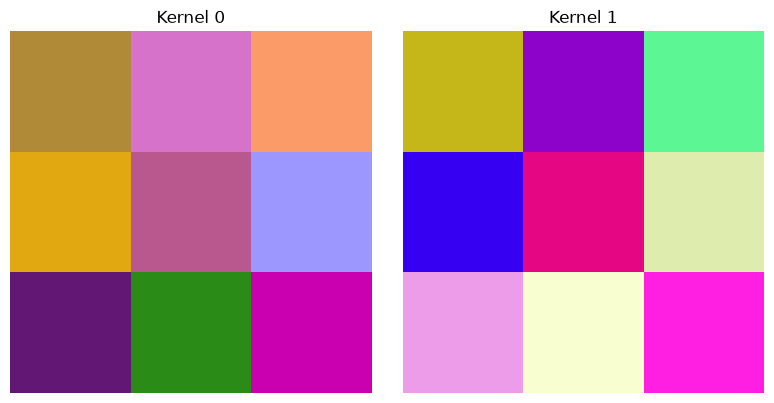

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 取出第 0、1 個 Kernel
kernel_0 = kernels[:, :, :, 0]
kernel_1 = kernels[:, :, :, 1]

# 正規化到 0~1，方便顯示成圖片
def normalize_kernel(kernel):
    kernel = kernel - kernel.min()
    kernel = kernel / (kernel.max() + 1e-8)
    return kernel

kernel_0_show = normalize_kernel(kernel_0)
kernel_1_show = normalize_kernel(kernel_1)

# 顯示兩個 Kernel
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(kernel_0_show)
plt.title("Kernel 0")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(kernel_1_show)
plt.title("Kernel 1")
plt.axis("off")

plt.tight_layout()
plt.show()

第一步：取一張測試圖片

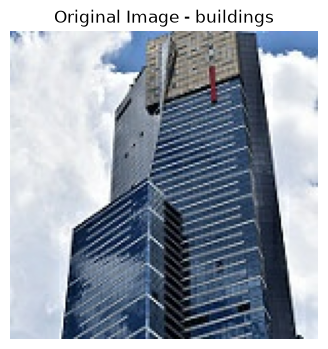

Image shape: (150, 150, 3)
True class: buildings


In [41]:
# 從 test_ds 取一個 batch
images, labels = next(iter(test_ds))

# 取第一張圖片
sample_image = images[0]
sample_label = labels[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title(f"Original Image - {class_names[sample_label.numpy()]}")
plt.axis("off")
plt.show()

print("Image shape:", sample_image.shape)
print("True class:", class_names[sample_label.numpy()])

第二步產生 Feature Map

In [42]:
# 建立一個只輸出第一個 Conv2D 結果的模型
feature_model = tf.keras.Model(
    inputs=plain_cnn.inputs,
    outputs=plain_cnn.layers[1].output
)

# 原本 sample_image 是 (150, 150, 3)
# 模型需要 batch 維度，所以變成 (1, 150, 150, 3)
input_image = tf.expand_dims(sample_image, axis=0)

# 取得第一層 Conv2D 的輸出
feature_maps = feature_model.predict(input_image)

print("Feature maps shape:", feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
Feature maps shape: (1, 148, 148, 32)


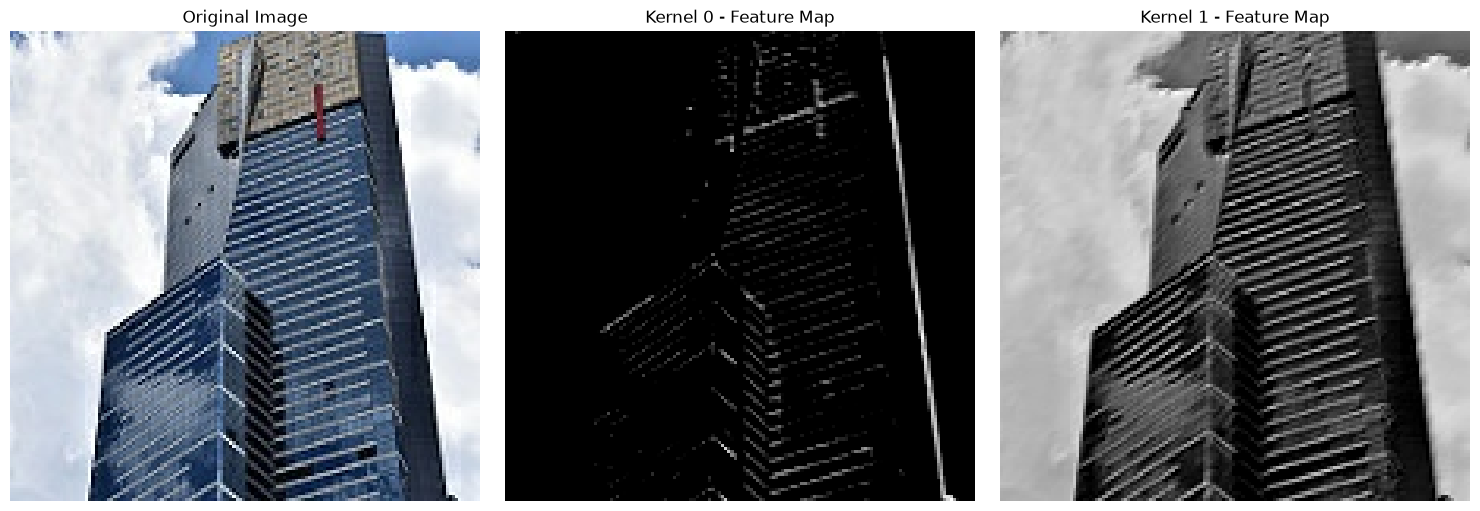

In [43]:
# 取出 Kernel 0 和 Kernel 1 對應的 Feature Map
feature_map_0 = feature_maps[0, :, :, 0]
feature_map_1 = feature_maps[0, :, :, 1]

plt.figure(figsize=(15, 5))

# 原始圖片
plt.subplot(1, 3, 1)
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title("Original Image")
plt.axis("off")

# Kernel 0 的 Feature Map
plt.subplot(1, 3, 2)
plt.imshow(feature_map_0, cmap="gray")
plt.title("Kernel 0 - Feature Map")
plt.axis("off")

# Kernel 1 的 Feature Map
plt.subplot(1, 3, 3)
plt.imshow(feature_map_1, cmap="gray")
plt.title("Kernel 1 - Feature Map")
plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Kernel 視覺化與分析

本實驗選擇訓練完成的 Plain CNN 第一個 Conv2D layer 進行 Kernel 視覺化。該層共有 32 個大小為 3×3×3 的 Kernel，本實驗選擇其中 Kernel 0 與 Kernel 1 進行觀察。

首先將兩個 Kernel 的權重正規化後進行視覺化，可以觀察到兩個 Kernel 具有不同的權重分布，表示模型在訓練過程中學習到了不同的特徵提取方式。

為了進一步分析 Kernel 的用途，將一張 buildings 類別的測試影像輸入 CNN，並觀察 Kernel 0 與 Kernel 1 所產生的 Feature Map。

Kernel 0 的 Feature Map 大部分區域反應較弱，但在建築物的輪廓、窗戶的水平線條以及部分明暗變化的位置具有較強的反應，因此推測此 Kernel 可能學習到類似邊緣與線條偵測的低階特徵。

Kernel 1 的 Feature Map 則保留了較多原始影像的整體結構，可以清楚觀察到建築物、天空以及建築表面的紋理與明暗差異，因此推測此 Kernel 對較廣泛的亮度、紋理及局部結構資訊具有反應。

由此可以觀察到，即使位於同一個卷積層，不同 Kernel 也會學習不同的影像特徵。這些低階特徵可以提供給後續卷積層，進一步組合成更複雜的影像特徵，最後用於影像分類。

# 使用 XAI 方法解釋模型預測結果，並分析模型所關注的影像區域

In [44]:
last_conv_layer = plain_cnn.get_layer("conv2d_2")

print("Layer name:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Layer name: conv2d_2
Output shape: (None, 34, 34, 128)


認模型對剛才建築圖片的預測

In [45]:
# 將圖片增加 batch 維度
input_image = tf.expand_dims(sample_image, axis=0)

# 模型進行預測
predictions = plain_cnn.predict(input_image)

# 找出預測機率最高的類別
predicted_index = tf.argmax(predictions[0]).numpy()
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index]

print("True class:", class_names[sample_label.numpy()])
print("Predicted class:", predicted_class)
print("Confidence:", float(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
True class: buildings
Predicted class: glacier
Confidence: 0.7645291686058044


建立 Grad-CAM 模型

In [47]:
# 建立 Grad-CAM 用的模型
grad_model = tf.keras.Model(
    inputs=plain_cnn.inputs,
    outputs=[
        plain_cnn.get_layer("conv2d_2").output,
        plain_cnn.layers[-1].output
    ]
)

print("Grad-CAM model created successfully!")

Grad-CAM model created successfully!


In [48]:
# 計算 Grad-CAM
with tf.GradientTape() as tape:
    # 取得最後卷積層輸出 + 模型預測
    conv_outputs, predictions = grad_model(input_image)

    # 取出模型預測類別 glacier 的分數
    class_score = predictions[:, predicted_index]

# 計算 glacier 分數對最後卷積層 Feature Maps 的梯度
grads = tape.gradient(class_score, conv_outputs)

print("Conv output shape:", conv_outputs.shape)
print("Gradient shape:", grads.shape)
print("Predicted class:", predicted_class)

Conv output shape: (1, 34, 34, 128)
Gradient shape: (1, 34, 34, 128)
Predicted class: glacier


合成 Grad-CAM Heatmap

In [49]:
# 對 gradient 的空間維度取平均
# 得到 128 個 Feature Maps 各自的重要程度
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# 去掉 batch 維度
conv_outputs = conv_outputs[0]

# 每張 Feature Map × 對 glacier 預測的重要程度
heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

# Grad-CAM 只保留正向影響
heatmap = tf.maximum(heatmap, 0)

# 正規化到 0~1
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

print("Heatmap shape:", heatmap.shape)
print("Heatmap min:", float(tf.reduce_min(heatmap)))
print("Heatmap max:", float(tf.reduce_max(heatmap)))

Heatmap shape: (34, 34)
Heatmap min: 0.0
Heatmap max: 0.999998152256012


原圖 + Grad-CAM Heatmap + 疊加結果

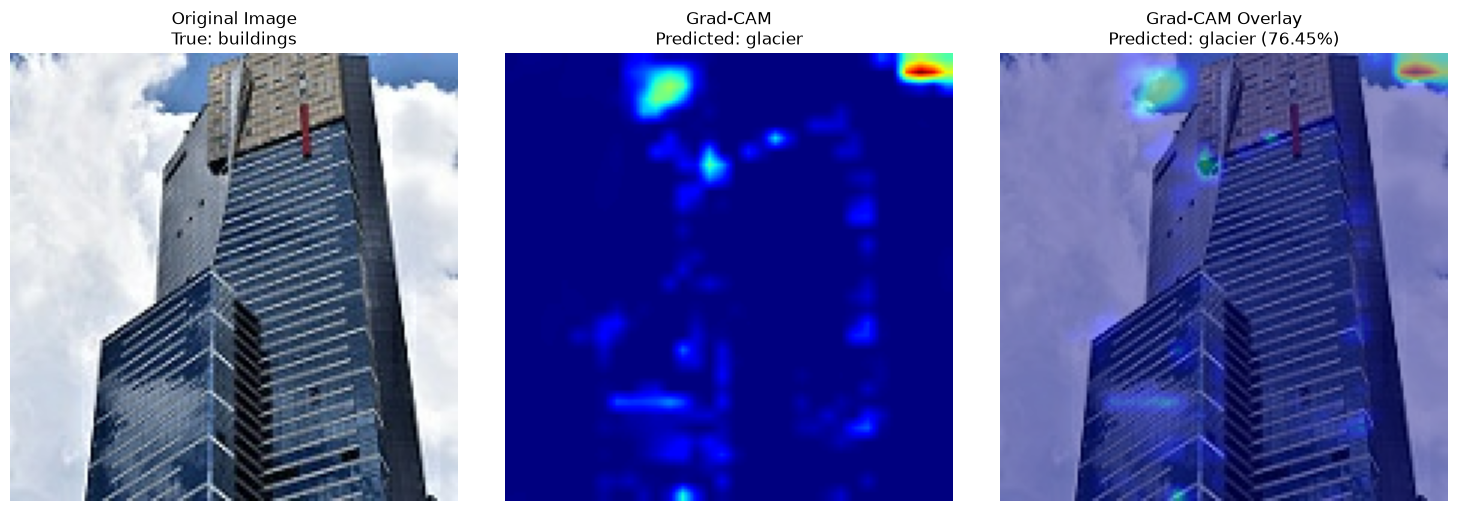

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 將 34x34 的 Grad-CAM 放大到原圖 150x150
heatmap_resized = tf.image.resize(
    heatmap[..., tf.newaxis],
    (150, 150)
).numpy().squeeze()

# 原始圖片
original_image = sample_image.numpy().astype("uint8")

plt.figure(figsize=(15, 5))

# 1. 原始圖片
plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title(f"Original Image\nTrue: {class_names[sample_label.numpy()]}")
plt.axis("off")

# 2. Grad-CAM Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title(f"Grad-CAM\nPredicted: {predicted_class}")
plt.axis("off")

# 3. 疊加 Grad-CAM
plt.subplot(1, 3, 3)
plt.imshow(original_image)
plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)
plt.title(
    f"Grad-CAM Overlay\n"
    f"Predicted: {predicted_class} ({confidence:.2%})"
)
plt.axis("off")

plt.tight_layout()
plt.show()

## XAI：使用 Grad-CAM 解釋模型預測結果

本實驗使用 Grad-CAM（Gradient-weighted Class Activation Mapping）分析 Plain CNN 的預測結果，觀察模型進行分類時主要關注影像中的哪些區域。

選取一張真實類別為 `buildings` 的測試影像進行分析。模型最終將此影像預測為 `glacier`，預測信心約為 76.45%，因此本次 Grad-CAM 分析的是模型在預測 `glacier` 時所關注的影像區域。

Grad-CAM 結果中，紅色與黃色代表對 `glacier` 預測具有較強正向貢獻的區域，而藍色區域的影響相對較弱。

從結果可以觀察到，模型較強的反應主要集中在影像上方的天空、雲層附近，而建築物本體大部分區域的反應相對較弱。這表示模型在將此影像分類為 `glacier` 時，可能較依賴上方明亮、偏白以及具有不規則紋理的區域，而沒有充分利用建築物本身規則的線條與結構特徵，因此造成此次錯誤分類。

透過 Grad-CAM，可以了解模型並非只提供最終分類結果，也可以進一步觀察哪些影像區域對模型的判斷產生較大的影響。此錯誤案例也顯示，模型可能學習到與類別相關但不夠可靠的視覺特徵。